Documents: 1008
Vocabulary size: 12690

Topic 0:
app, users, like, new, ai, google, apps, company, time, features, year, apple

Topic 1:
data, security, api, server, use, user, access, code, request, key, like, database

Topic 2:
ai, code, data, use, like, model, models, time, just, tools, real, need

Topic 3:
code, software, security, development, tools, testing, teams, developers, devops, application, help, ci

Topic 4:
said, company, data, people, new, just, time, meta, companies, security, techcrunch, like

Topic 5:
ai, openai, models, said, company, new, chatgpt, model, agents, like, nvidia, companies

Topic 6:
company, million, billion, startup, ai, raised, investors, data, capital, round, year, series

Topic distribution:
dominant_topic
0    147
1    161
2    285
3     50
4    162
5     97
6    106
Name: count, dtype: int64


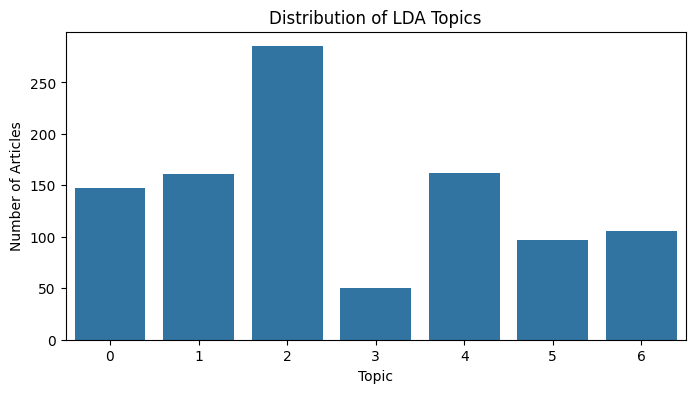

Saved: ../data/processed/articles_with_topics.csv


In [1]:
# ===============================
# LDA TOPIC MODELING
# ONE CELL
# ===============================

import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation

# -------------------------------
# 1) Load cleaned dataset
# -------------------------------
df = pd.read_csv("../data/processed/articles_cleaned.csv")

texts = df["full_text"].astype(str).tolist()
print("Documents:", len(texts))

# -------------------------------
# 2) Vectorization (Bag of Words)
# -------------------------------
vectorizer = CountVectorizer(
    max_df=0.85,        # ignore very common words
    min_df=5,           # ignore very rare words
    stop_words="english",
    ngram_range=(1, 2)  # unigrams + bigrams
)

X = vectorizer.fit_transform(texts)
print("Vocabulary size:", len(vectorizer.get_feature_names_out()))

# -------------------------------
# 3) Train LDA
# -------------------------------
N_TOPICS = 7   # 🔥 matches your project topic number

lda = LatentDirichletAllocation(
    n_components=N_TOPICS,
    random_state=42,
    learning_method="batch",
    max_iter=20,
    evaluate_every=2,
    n_jobs=-1
)

lda.fit(X)

# -------------------------------
# 4) Display top words per topic
# -------------------------------
def display_topics(model, feature_names, n_top_words=10):
    topics = {}
    for topic_idx, topic in enumerate(model.components_):
        top_words = [feature_names[i] for i in topic.argsort()[:-n_top_words - 1:-1]]
        topics[f"Topic {topic_idx}"] = top_words
        print(f"\nTopic {topic_idx}:")
        print(", ".join(top_words))
    return topics

feature_names = vectorizer.get_feature_names_out()
topics = display_topics(lda, feature_names, n_top_words=12)

# -------------------------------
# 5) Assign dominant topic per article
# -------------------------------
topic_distributions = lda.transform(X)

df["dominant_topic"] = topic_distributions.argmax(axis=1)
df["topic_confidence"] = topic_distributions.max(axis=1)

print("\nTopic distribution:")
print(df["dominant_topic"].value_counts().sort_index())

# -------------------------------
# 6) Visualize topic distribution
# -------------------------------
plt.figure(figsize=(8, 4))
sns.countplot(x="dominant_topic", data=df)
plt.title("Distribution of LDA Topics")
plt.xlabel("Topic")
plt.ylabel("Number of Articles")
plt.show()

# -------------------------------
# 7) Save results
# -------------------------------
df.to_csv("../data/processed/articles_with_topics.csv", index=False)

print("Saved: ../data/processed/articles_with_topics.csv")


In [3]:
import pickle

with open("../models/lda_model.pkl", "wb") as f:
    pickle.dump(lda, f)

with open("../models/vectorizer.pkl", "wb") as f:
    pickle.dump(vectorizer, f)
